# 04 - Evaluation + Threshold Calibration

**Goal**: Produce the figures we need for the PDF report, and calibrate the alert threshold from data.

**What this notebook does**:
1. Load the trained model + re-create the test split (same `random_state` as notebook 03)
2. Test-set classification report (untouched until now)
3. Confusion matrix figure → `../report/figures/04_confusion_matrix.png`
4. Per-class ROC curves → `../report/figures/04_roc_curves.png`
5. Feature importance bar chart → `../report/figures/04_feature_importance.png`
6. **Your decision**: pick a target false-positive rate; calibrate the alert threshold against it
7. Save the calibrated threshold into `metadata.json` - the runtime reads it to decide when to raise alerts

**Important**: test-set predictions happen **once**. We never go back and tune anything after looking at test performance, or we contaminate the 'held-out' nature of it. Threshold calibration uses the **validation** set.

In [1]:
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')

DATA_DIR   = Path('../data/processed')
MODELS_DIR = Path('../models')
FIG_DIR    = Path('../report/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_PATH  = DATA_DIR / 'cleaned.parquet'
FEATURES_PATH = MODELS_DIR / 'feature_names.json'
METADATA_PATH = MODELS_DIR / 'metadata.json'
MODEL_PATH    = MODELS_DIR / 'detector.pkl'

RANDOM_STATE = 42

## 1. Load model + re-create the splits

Same `random_state` and same split ratios as notebook 03, `train_test_split` is deterministic, so we get the identical test set back without re-training.

In [2]:
clf      = joblib.load(MODEL_PATH)
metadata = json.loads(METADATA_PATH.read_text())
FEATURES = metadata['feature_names']
CLASS_NAMES = metadata['class_names']

df = pd.read_parquet(PARQUET_PATH)
X = df[FEATURES].to_numpy(dtype=np.float64)
y = df['label'].to_numpy(dtype=int)

# Identical split to notebook 03
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15 / 0.85, stratify=y_trainval, random_state=RANDOM_STATE,
)

print(f'Train: {len(y_train):,}  Val: {len(y_val):,}  Test: {len(y_test):,}')

Train: 306,044  Val: 65,581  Test: 65,582


## 2. Test-set classification report

The "real" number for the report. Run once, report once.

In [3]:
y_test_pred  = clf.predict(X_test)
y_test_proba = clf.predict_proba(X_test)

print(classification_report(y_test, y_test_pred, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

      benign     0.9994    0.9998    0.9996     32756
        ddos     0.9997    0.9990    0.9993     19203
    portscan     0.9999    0.9999    0.9999     13623

    accuracy                         0.9996     65582
   macro avg     0.9996    0.9995    0.9996     65582
weighted avg     0.9996    0.9996    0.9996     65582



## 3. Confusion matrix

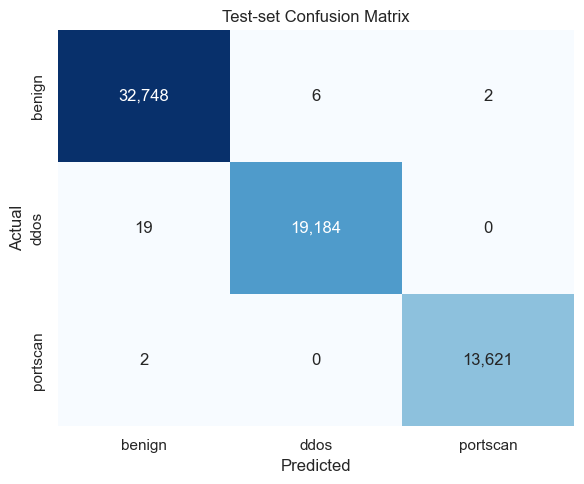

Saved: ..\report\figures\04_confusion_matrix.png


In [4]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar=False, ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Test-set Confusion Matrix')
plt.tight_layout()

out = FIG_DIR / '04_confusion_matrix.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'Saved: {out}')

## 4. Per-class ROC curves (one-vs-rest)

For each class, we treat it as "positive" and the other two as "negative", then plot the trade-off between true-positive rate and false-positive rate as we sweep the decision threshold.

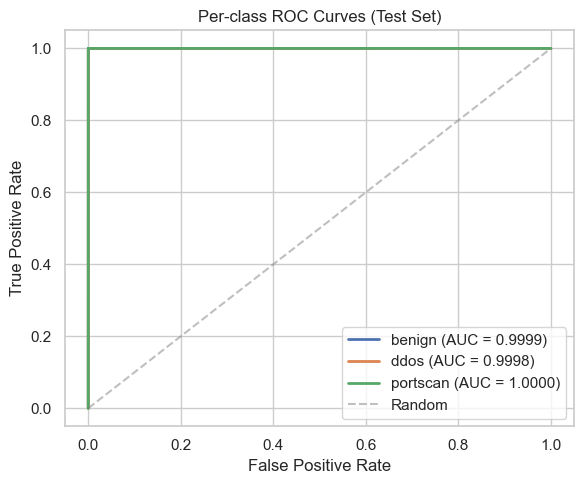

Saved: ..\report\figures\04_roc_curves.png


In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
for class_idx, cname in enumerate(CLASS_NAMES):
    y_binary  = (y_test == class_idx).astype(int)
    score     = y_test_proba[:, class_idx]
    fpr, tpr, _ = roc_curve(y_binary, score)
    auc = roc_auc_score(y_binary, score)
    ax.plot(fpr, tpr, label=f'{cname} (AUC = {auc:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Per-class ROC Curves (Test Set)')
ax.legend(loc='lower right')
plt.tight_layout()

out = FIG_DIR / '04_roc_curves.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'Saved: {out}')

## 5. Feature importance

Which of your 15 features did the Random Forest actually lean on? This is the evidence you need for the report: feature importance here *is* the answer to "did my feature selection make sense?".

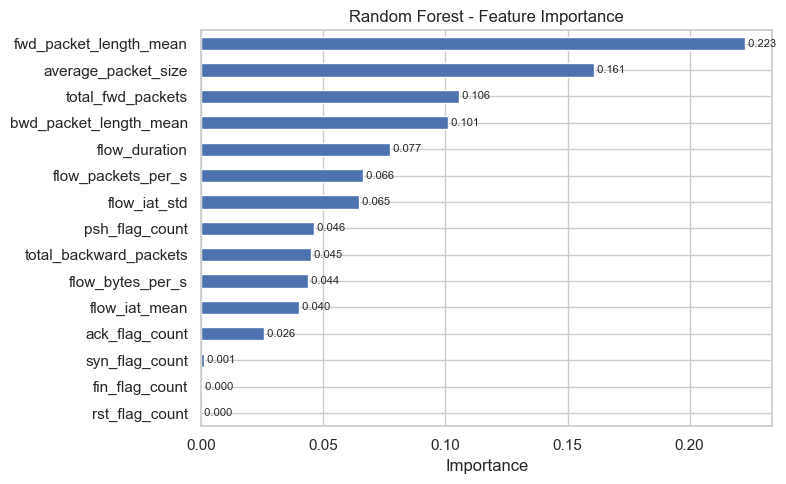

Saved: ..\report\figures\04_feature_importance.png

Top 5 most important:
  0.2228  fwd_packet_length_mean
  0.1608  average_packet_size
  0.1057  total_fwd_packets
  0.1008  bwd_packet_length_mean
  0.0773  flow_duration

Bottom 3 (candidates for removal if ever needed):
  0.0000  rst_flag_count
  0.0002  fin_flag_count
  0.0011  syn_flag_count


In [6]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Random Forest - Feature Importance')
ax.set_xlabel('Importance')
for i, v in enumerate(importances.values):
    ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
plt.tight_layout()

out = FIG_DIR / '04_feature_importance.png'
fig.savefig(out, dpi=120)
plt.show()
print(f'Saved: {out}')
print()
print('Top 5 most important:')
for name, imp in importances.tail(5).iloc[::-1].items():
    print(f'  {imp:.4f}  {name}')
print('\nBottom 3 (candidates for removal if ever needed):')
for name, imp in importances.head(3).items():
    print(f'  {imp:.4f}  {name}')

## 6. Threshold Calibration

### Why this decision matters

At runtime `detector.py` calls `model.predict_proba(flow)` and gets three probabilities, one per class. It must then decide:

> *"Is the attack probability high enough to raise an alert on the dashboard?"*

That "high enough" is our threshold. If we set it too low, benign flows get misclassified as attacks and operators drown in false alarms. If we set it too high, real attacks slip through.

Rather than guess the threshold, we **calibrate it against a target false-positive rate (FPR)** measured on benign validation flows. We answer the question: *"if I'm willing to accept X% of benign flows being mislabeled, what threshold on `P(attack)` gives me exactly that rate?"*

### Industry rough guide

| FPR target | Meaning | Use case |
|---|---|---|
| **0.01** (1%) | 1 false alarm per 100 benign flows | Loose - fine for a classroom demo with low traffic |
| **0.001** (0.1%) | 1 false alarm per 1,000 benign flows | Tight - reasonable for a live SOC with a human reviewer |
| **0.0001** (0.01%) | 1 false alarm per 10,000 benign flows | Production-grade - needs a near-perfect model |

Our validation F1 is ~0.9997, so anything down to `0.0001` is mathematically achievable. **But** remember: the model was trained on CICIDS2017 lab data. At runtime, benign traffic on *your* machine won't look identical. A tight calibration risks rejecting too much at runtime. A looser calibration is more forgiving.

### Decision

Edit the `TARGET_FPR` value in the cell below. I recommend **`0.001`** for this project - strict enough to matter, loose enough to tolerate domain shift between CICIDS2017 and your loopback traffic.

In [7]:
# =====================================================================
#  DECISION - target false-positive rate on benign traffic
# =====================================================================

TARGET_FPR: float = 0.001  # <-- adjust if you want tighter/looser

assert 0.00001 <= TARGET_FPR <= 0.1, 'Pick an FPR between 0.00001 and 0.1'
print(f'Target FPR: {TARGET_FPR*100:.3f}% of benign flows')

Target FPR: 0.100% of benign flows


### Calibration (automatic)

The code below walks through every benign validation flow, computes `P(attack) = max(P(ddos), P(portscan))`, sorts those values, and finds the threshold such that only `TARGET_FPR` fraction of benign flows have `P(attack)` above it.

In [8]:
# Use the VALIDATION set (not test) for calibration to keep test pure.
y_val_proba = clf.predict_proba(X_val)

# For each benign flow in val, what's the model's max P(attack)?
# Column 0 is benign; attack columns are 1 (ddos) and 2 (portscan).
benign_mask = (y_val == 0)
benign_attack_probs = y_val_proba[benign_mask, 1:].max(axis=1)

# Find the threshold t such that P(benign flow has P(attack) >= t) == TARGET_FPR
# Equivalent to the (1 - TARGET_FPR) quantile of the sorted probabilities.
threshold = float(np.quantile(benign_attack_probs, 1 - TARGET_FPR))

# Sanity: compute the achieved FPR on the validation benign set
achieved_fpr = float((benign_attack_probs >= threshold).mean())

print(f'Calibrated threshold:           {threshold:.4f}')
print(f'Target FPR (benign validation): {TARGET_FPR*100:.4f}%')
print(f'Achieved FPR at threshold:      {achieved_fpr*100:.4f}%')
print()
print('Interpretation:')
print(f'  At runtime, detector.py will raise an alert when')
print(f'  max(P(ddos), P(portscan)) >= {threshold:.4f}')

Calibrated threshold:           0.1322
Target FPR (benign validation): 0.1000%
Achieved FPR at threshold:      0.1007%

Interpretation:
  At runtime, detector.py will raise an alert when
  max(P(ddos), P(portscan)) >= 0.1322


### Recall check - does our threshold still catch attacks?

A calibrated threshold controls false positives, but we also need to confirm it doesn't accidentally kill recall on actual attacks.

In [9]:
# Among real attacks in val: what fraction have max(P(attack)) >= threshold?
for class_idx in (1, 2):  # ddos, portscan
    cname = CLASS_NAMES[class_idx]
    mask  = (y_val == class_idx)
    attack_probs = y_val_proba[mask, 1:].max(axis=1)
    caught = (attack_probs >= threshold).mean()
    print(f'  {cname:<9} recall at threshold = {caught*100:.2f}%')

print()
print('If any recall is < 95%, you may want to loosen TARGET_FPR.')
print('If recall is ~100%, the threshold is comfortable - we could even tighten further.')

  ddos      recall at threshold = 99.98%
  portscan  recall at threshold = 99.98%

If any recall is < 95%, you may want to loosen TARGET_FPR.
If recall is ~100%, the threshold is comfortable - we could even tighten further.


## 7. Save calibrated threshold into `metadata.json`

This is the **final contract-update for the runtime**. `detector.py` will read this value at startup. If this file is missing or corrupt, detection fails closed (no alerts) instead of firing randomly.

In [10]:
test_accuracy = float((y_test_pred == y_test).mean())
test_macro_f1 = float(classification_report(y_test, y_test_pred, output_dict=True)['macro avg']['f1-score'])

metadata['evaluation'] = {
    'test_accuracy': round(test_accuracy, 4),
    'test_macro_f1': round(test_macro_f1, 4),
    'test_confusion_matrix': cm.tolist(),
}
metadata['severity_thresholds'] = {
    'alert_threshold':    round(threshold, 4),
    'target_fpr':         TARGET_FPR,
    'achieved_fpr_val':   round(achieved_fpr, 6),
    'calibrated_on':      'validation benign flows',
}
metadata['evaluated_at'] = datetime.now(timezone.utc).isoformat()

METADATA_PATH.write_text(json.dumps(metadata, indent=2))

print(f'Saved: {METADATA_PATH}')
print()
print('Final severity_thresholds block:')
print(json.dumps(metadata['severity_thresholds'], indent=2))

Saved: ..\models\metadata.json

Final severity_thresholds block:
{
  "alert_threshold": 0.1322,
  "target_fpr": 0.001,
  "achieved_fpr_val": 0.001007,
  "calibrated_on": "validation benign flows"
}


## Summary - offline phase complete

We now have everything the runtime needs:

```
models/
├── detector.pkl          ← the trained Random Forest
├── feature_names.json    ← feature contract (name + order)
├── metadata.json         ← label map, units, thresholds, metrics
└── column_rename_map.json ← audit trail from notebook 02

report/figures/
├── 01_class_distribution.png
├── 04_confusion_matrix.png
├── 04_roc_curves.png
└── 04_feature_importance.png   ← all four figures ready for the report
```

**Next**: we leave the notebooks behind and start on `src/` - the online runtime. First module: `flow_builder.py`, the 5-tuple flow state machine that turns Scapy packets into `FlowRecord`s.
